# **Import Libraries**

In [154]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

# **Load Data**

In [155]:
nav = pd.read_csv("nav_history.csv")

benchmark = pd.read_csv("benchmark_indices.csv")

fund_master = pd.read_csv("fund_master.csv")

In [156]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# **Merge**

In [157]:
nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# **Daily Returns**

Helped understand daily fund volatility and identify abnormal return patterns or extreme market movements. A near-normal distribution indicates stable fund behavior.

In [158]:
nav = nav.sort_values(["scheme_name", "date"])

nav["daily_return"] = nav.groupby("scheme_name")["nav"].pct_change()

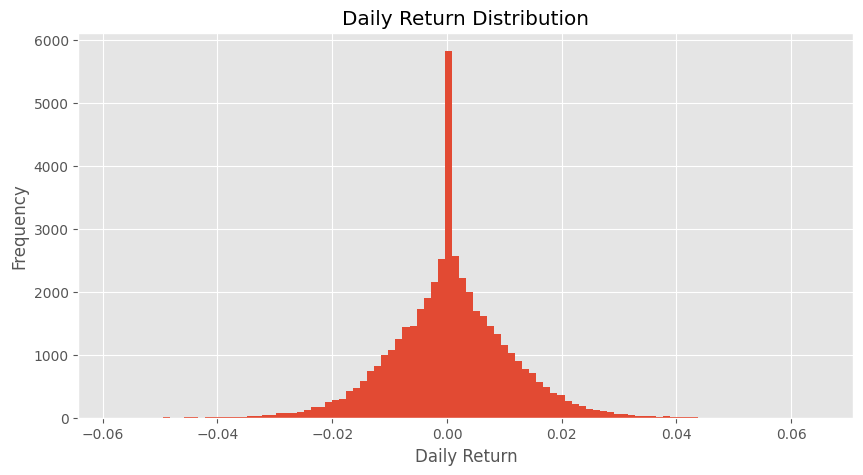

In [159]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(bins=100)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()



---



# **CAGR for 1yr, 3yr, 5yr**

Identified long-term wealth creators and compared short-, medium-, and long-term fund performance. Higher CAGR indicates stronger long-term growth potential.

In [160]:
def calculate_cagr(df, years):

    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"]>=start_date]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    return ((end_nav/start_nav)**(1/years))-1

In [161]:
results=[]

for scheme,grp in nav.groupby("scheme_name"):

    grp=grp.sort_values("date")

    results.append({
        "Scheme":scheme,
        "1Y CAGR":calculate_cagr(grp,1),
        "3Y CAGR":calculate_cagr(grp,3),
        "5Y CAGR":calculate_cagr(grp,5)
    })

cagr_table=pd.DataFrame(results)

cagr_table.head()

,Scheme,1Y CAGR,3Y CAGR,5Y CAGR
0,ABSL Frontline Equity Fund - Regular - Growth,0.479241,0.289677,0.204427
1,ABSL Liquid Fund - Regular - Growth,0.072366,0.063158,0.057057
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533
3,Axis Bluechip Fund - Direct - Growth,0.197667,0.208168,0.069174
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259,0.055826




---



# **Sharpe Ratio**

Determined which funds generated the highest return per unit of total risk. Higher Sharpe Ratio indicates more efficient risk-adjusted performance.

In [162]:
rf=0.065

def sharpe_ratio(df):
    r=df["daily_return"].dropna()
    annual_return=r.mean()*252
    annual_std=r.std()*np.sqrt(252)
    return (annual_return-rf)/annual_std

In [163]:
sharpe=[]

for scheme,grp in nav.groupby("scheme_name"):
    sharpe.append([scheme,sharpe_ratio(grp)])

sharpe_df=pd.DataFrame(
    sharpe,
    columns=["Scheme","Sharpe"]
)

sharpe_df=sharpe_df.sort_values(
    "Sharpe",
    ascending=False
)

print(sharpe_df)

                                               Scheme    Sharpe
25      Mirae Asset Large Cap Fund - Regular - Growth  1.448291
22             Kotak Flexicap Fund - Regular - Growth  1.306744
26      Mirae Asset Tax Saver Fund - Regular - Growth  1.234930
33          SBI Bluechip Fund - Regular Plan - Growth  1.208267
18           ICICI Pru Midcap Fund - Regular - Growth  1.180101
7                  DSP Midcap Fund - Regular - Growth  1.132122
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  1.093699
30     Nippon India Large Cap Fund - Regular - Growth  1.081659
0       ABSL Frontline Equity Fund - Regular - Growth  1.027213
15          ICICI Pru Bluechip Fund - Direct - Growth  1.026524
5                 Axis Midcap Fund - Regular - Growth  0.998231
32           SBI Bluechip Fund - Direct Plan - Growth  0.953279
8               DSP Small Cap Fund - Regular - Growth  0.949796
36         SBI Small Cap Fund - Regular Plan - Growth  0.945308
24  Mirae Asset Emerging Bluechip Fund -



---



# **Sortino Ratio**

Evaluated downside risk instead of total volatility, making it more suitable for long-term investors focused on capital preservation. Higher Sortino Ratio indicates better downside protection

In [164]:
def sortino_ratio(df):
    r=df["daily_return"].dropna()
    downside=r[r<0]
    downside_std=downside.std()*np.sqrt(252)
    annual_return=r.mean()*252
    return (annual_return-rf)/downside_std

In [165]:
sortino=[]

for scheme,grp in nav.groupby("scheme_name"):
    sortino.append([
        scheme,
        sortino_ratio(grp)
    ])

sortino_df=pd.DataFrame(
    sortino,
    columns=["Scheme","Sortino"]
).sort_values(
    "Sortino",
    ascending=False
)

print(sortino_df)

                                               Scheme   Sortino
25      Mirae Asset Large Cap Fund - Regular - Growth  2.385644
22             Kotak Flexicap Fund - Regular - Growth  2.364320
26      Mirae Asset Tax Saver Fund - Regular - Growth  2.146914
33          SBI Bluechip Fund - Regular Plan - Growth  2.140267
18           ICICI Pru Midcap Fund - Regular - Growth  2.029353
7                  DSP Midcap Fund - Regular - Growth  1.875101
30     Nippon India Large Cap Fund - Regular - Growth  1.850133
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  1.829134
15          ICICI Pru Bluechip Fund - Direct - Growth  1.805294
0       ABSL Frontline Equity Fund - Regular - Growth  1.799563
5                 Axis Midcap Fund - Regular - Growth  1.703797
36         SBI Small Cap Fund - Regular Plan - Growth  1.675317
24  Mirae Asset Emerging Bluechip Fund - Regular -...  1.632741
8               DSP Small Cap Fund - Regular - Growth  1.619793
32           SBI Bluechip Fund - Direct 



---



# **Alpha & Beta**

Alpha measures fund manager's ability to generate excess returns beyond the benchmark, while Beta measures market sensitivity. Positive Alpha indicates value addition, whereas Beta identifies aggressive or defensive funds.

In [166]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

In [167]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna()

In [171]:
nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [172]:
alpha_beta_results = []

# Loop through every fund
for fund_code in nav["amfi_code"].unique():
    fund_data = nav[
        nav["amfi_code"] == fund_code
    ].copy()

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    # Remove missing values
    merged = merged.dropna()

    # Need enough observations
    if len(merged) < 30:
        continue

    # Independent variable (Market)
    x = merged["benchmark_return"]

    # Dependent variable (Fund)
    y = merged["daily_return"]

    # OLS Regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    # Annual Alpha
    alpha = intercept * 252

    # Beta
    beta = slope

    # R-Squared
    r_squared = r_value ** 2

    # Store Result
    alpha_beta_results.append({
        "amfi_code": fund_code,
        "scheme_name": merged["scheme_name"].iloc[0],
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": r_squared,
        "P_value": p_value,
        "Std_Error": std_err
    })

# Convert to DataFrame
alpha_beta = pd.DataFrame(alpha_beta_results)

# Rank by Alpha
alpha_beta = alpha_beta.sort_values(
    "Alpha",
    ascending=False
)

alpha_beta.head()

,amfi_code,scheme_name,Alpha,Beta,R_squared,P_value,Std_Error
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.414258e-04,0.687179,0.057589
39,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,3.532991e-05,0.840494,0.056904
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,1.345534e-07,0.990090,0.044192
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,1.748889e-04,0.654295,0.040485
30,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,3.430543e-04,0.530528,0.036388


In [173]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

## **Interpretation**

In [174]:
print(alpha_beta.describe())

           amfi_code      Alpha       Beta     R_squared    P_value  Std_Error
count      40.000000  40.000000  40.000000  4.000000e+01  40.000000  40.000000
mean   120247.000000   0.159085  -0.001958  6.087700e-04   0.545393   0.034223
std     14534.998667   0.087528   0.035194  7.265363e-04   0.280488   0.015284
min    100016.000000   0.028969  -0.066951  1.345534e-07   0.073339   0.001131
25%    118632.750000   0.068612  -0.023937  5.495723e-05   0.275811   0.031705
50%    119551.500000   0.162326  -0.000067  3.455513e-04   0.529040   0.033325
75%    120842.250000   0.221723   0.017026  1.035467e-03   0.802038   0.041654
max    149324.000000   0.303370   0.103497  2.793007e-03   0.990090   0.059066


In [175]:
positive_alpha = alpha_beta[
    alpha_beta["Alpha"] > 0
]

print(positive_alpha)

    amfi_code                                        scheme_name     Alpha  \
21     119598         SBI Small Cap Fund - Regular Plan - Growth  0.303370   
39     149324              DSP Small Cap Fund - Regular - Growth  0.300579   
25     120505           ICICI Pru Midcap Fund - Regular - Growth  0.292636   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.282704   
30     120843             Kotak Flexicap Fund - Regular - Growth  0.273305   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.269838   
38     149323                 DSP Midcap Fund - Regular - Growth  0.265986   
16     119094                Axis Midcap Fund - Regular - Growth  0.260767   
19     119551          SBI Bluechip Fund - Regular Plan - Growth  0.232010   
9      118632     Nippon India Large Cap Fund - Regular - Growth  0.218294   
3      101206      ABSL Frontline Equity Fund - Regular - Growth

In [176]:
high_beta = alpha_beta[
    alpha_beta["Beta"] > 1
]

print(high_beta)

Empty DataFrame
Columns: [amfi_code, scheme_name, Alpha, Beta, R_squared, P_value, Std_Error]
Index: []


In [177]:
low_beta = alpha_beta[
    alpha_beta["Beta"] < 1
]

print(low_beta)

    amfi_code                                        scheme_name     Alpha  \
21     119598         SBI Small Cap Fund - Regular Plan - Growth  0.303370   
39     149324              DSP Small Cap Fund - Regular - Growth  0.300579   
25     120505           ICICI Pru Midcap Fund - Regular - Growth  0.292636   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.282704   
30     120843             Kotak Flexicap Fund - Regular - Growth  0.273305   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.271954   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.269838   
38     149323                 DSP Midcap Fund - Regular - Growth  0.265986   
16     119094                Axis Midcap Fund - Regular - Growth  0.260767   
19     119551          SBI Bluechip Fund - Regular Plan - Growth  0.232010   
9      118632     Nippon India Large Cap Fund - Regular - Growth  0.218294   
3      101206      ABSL Frontline Equity Fund - Regular - Growth



---



# **Maximum Drawdown**

Measured downside risk and capital loss during market corrections. Funds with lower drawdowns generally offer better capital preservation.

In [178]:
def max_drawdown(df):
    running_max=df["nav"].cummax()
    drawdown=df["nav"]/running_max-1
    mdd=drawdown.min()
    end=drawdown.idxmin()
    start=df.loc[:end,"nav"].idxmax()

    return mdd,start,end

In [179]:
drawdowns=[]

for scheme,grp in nav.groupby("scheme_name"):
    grp=grp.reset_index(drop=True)
    dd,start,end=max_drawdown(grp)
    drawdowns.append([
        scheme,
        dd,
        grp.loc[start,"date"],
        grp.loc[end,"date"]
    ])

drawdown_df=pd.DataFrame(
    drawdowns,

    columns=["Scheme", "Max Drawdown", "Start", "End"]
)

print(drawdown_df.sort_values("Max Drawdown", ascending=False))

                                               Scheme  Max Drawdown  \
17           ICICI Pru Liquid Fund - Regular - Growth     -0.000977   
23               Kotak Liquid Fund - Regular - Growth     -0.001163   
1                 ABSL Liquid Fund - Regular - Growth     -0.001622   
12       HDFC Short Term Debt Fund - Regular - Growth     -0.043083   
34       SBI Magnum Gilt Fund - Regular Plan - Growth     -0.043287   
28  Nippon India Gilt Securities Fund - Regular - ...     -0.083164   
39         UTI Nifty 50 Index Fund - Regular - Growth     -0.108599   
25      Mirae Asset Large Cap Fund - Regular - Growth     -0.112657   
0       ABSL Frontline Equity Fund - Regular - Growth     -0.112916   
27                     Nippon India ETF Nifty 50 BeES     -0.115115   
32           SBI Bluechip Fund - Direct Plan - Growth     -0.118035   
15          ICICI Pru Bluechip Fund - Direct - Growth     -0.125883   
22             Kotak Flexicap Fund - Regular - Growth     -0.129740   
16    



---



# **Fund Scorecard (0–100)**

Created a single objective ranking system to compare mutual funds using both return and risk metrics instead of relying on one performance indicator.

In [180]:
# Make all DataFrames use the same column name
cagr_table = cagr_table.rename(columns={"Scheme": "scheme_name"})
sharpe_df = sharpe_df.rename(columns={"Scheme": "scheme_name"})
drawdown_df = drawdown_df.rename(columns={"Scheme": "scheme_name"})


# If alpha_beta has 'Scheme', rename it
if "Scheme" in alpha_beta.columns:
    alpha_beta = alpha_beta.rename(columns={"Scheme": "scheme_name"})

In [181]:
score = cagr_table.copy()

# Merge all metrics
score = score.merge(sharpe_df, on="scheme_name")
score = score.merge(alpha_beta[["scheme_name", "Alpha"]], on="scheme_name")
score = score.merge(drawdown_df[["scheme_name", "Max Drawdown"]], on="scheme_name")
score = score.merge(
    fund_master[["scheme_name", "expense_ratio_pct"]],
    on="scheme_name"
)

# Rankings
score["Return Rank"] = score["3Y CAGR"].rank(ascending=False)
score["Sharpe Rank"] = score["Sharpe"].rank(ascending=False)
score["Alpha Rank"] = score["Alpha"].rank(ascending=False)

# Lower expense ratio is better
score["Expense Rank"] = score["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown is better
score["DD Rank"] = score["Max Drawdown"].rank(ascending=False)

# Final Score
score["Score"] = (
    0.30 * score["Return Rank"] +
    0.25 * score["Sharpe Rank"] +
    0.20 * score["Alpha Rank"] +
    0.15 * score["Expense Rank"] +
    0.10 * score["DD Rank"]
)

score["Score"] = 100 * score["Score"] / score["Score"].max()

score = score.sort_values("Score", ascending=False)

score.head()

,scheme_name,1Y CAGR,3Y CAGR,5Y CAGR,Sharpe,Alpha,Max Drawdown,expense_ratio_pct,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,DD Rank,Score
38,UTI Mid Cap Fund - Regular - Growth,-0.167975,-0.007674,0.010303,-0.205832,0.028969,-0.280011,1.51,37.0,36.0,40.0,24.5,35.0,100.000000
14,HDFC Top 100 Fund - Regular Plan - Growth,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.247344,1.55,35.0,35.0,39.0,32.0,34.0,99.929128
6,Axis Small Cap Fund - Regular - Growth,-0.427976,-0.117058,0.013376,-0.075974,0.048016,-0.516778,1.38,40.0,33.0,37.0,17.0,39.0,96.669029
2,ABSL Small Cap Fund - Regular - Growth,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.354469,1.53,39.0,28.0,27.0,28.5,38.0,91.211906
4,Axis Bluechip Fund - Regular - Growth,0.016091,0.005259,0.055826,0.030785,0.068995,-0.144016,1.64,36.0,31.0,30.0,39.5,16.0,90.928420


In [182]:
score.to_csv("fund_scorecard.csv", index=False)



---



# **Top 5 vs Nifty 50 & Nifty 100**

Compared the Top 5 ranked mutual funds with the NIFTY 50 and NIFTY 100 benchmarks over the last three years using a performance chart. This analysis helped identify funds that consistently outperformed the market and evaluated the effectiveness of active fund management against benchmark indices.

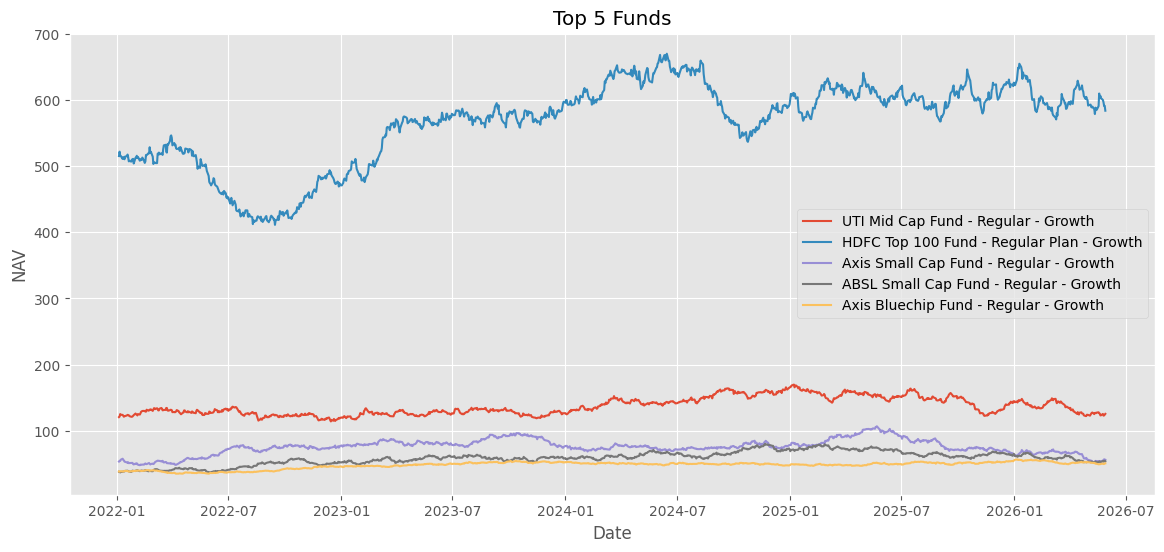

In [183]:
top5 = score.head(5)["scheme_name"]

plt.figure(figsize=(14,6))

for scheme in top5:

    temp = nav[nav["scheme_name"] == scheme]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.legend()
plt.title("Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()


---



# **Tracking Error**

Calculated the Tracking Error for each fund by comparing its daily returns with the NIFTY 100 benchmark. This metric measured how closely a fund tracked the benchmark, where a lower Tracking Error indicated closer benchmark replication and a higher value reflected more active portfolio management.

In [184]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [185]:
benchmark = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

In [186]:
tracking = []

for scheme, grp in nav.groupby("scheme_name"):

    temp = pd.merge(
        grp,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    te = (temp["daily_return"] - temp["benchmark_return"]).std() * np.sqrt(252)

    tracking.append([scheme, te])

tracking_df = pd.DataFrame(
    tracking,
    columns=["Scheme", "Tracking Error"]
)

tracking_df.head()

,Scheme,Tracking Error
0,ABSL Frontline Equity Fund - Regular - Growth,0.192706
1,ABSL Liquid Fund - Regular - Growth,0.128957
2,ABSL Small Cap Fund - Regular - Growth,0.292117
3,Axis Bluechip Fund - Direct - Growth,0.187900
4,Axis Bluechip Fund - Regular - Growth,0.189082
